# Load Packages and Data

In [55]:
from data import build_all
from pitch_suggestions import suggest_pitches, plot_pitch_clusters, run_suggest_pitches_bulk
import warnings
import pandas as pd

pd.set_option('display.max_columns', None)

warnings.filterwarnings("ignore")

In [54]:
# import importlib
# import pitch_suggestions

# importlib.reload(pitch_suggestions)

<module 'pitch_suggestions' from '/Users/kids/Pitcher Similarity/pitch_suggestions.py'>

In [2]:
data = build_all(live=False)

statcast_clean  = data['statcast_clean']
pitch_type_summ = data['pitch_type_summ']
pitcher_summ    = data['pitcher_summ']
pitcher_summ_r  = data['pitcher_summ_r']
pitcher_summ_l  = data['pitcher_summ_l']
pitch_type_r  = data['pitch_type_r']
pitch_type_l  = data['pitch_type_l']

statcast_clean_25 = statcast_clean[statcast_clean['game_year'] == 2025]

# Identify Pitch Opportunities

In [3]:
BIOMECH_FEATURES    = ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball']
PITCH_CHAR_FEATURES = ['release_speed', 'pfx_x', 'pfx_z']

### Bello Example

Example of what the tool recommends

In [42]:
b_bello = suggest_pitches(
    target_pitcher='Bello, Brayan',
    pitcher_summ=pitcher_summ_r,
    pitch_type_summ=pitch_type_r,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.5,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

In [43]:
b_bello['status']

'ok'

In [44]:
b_bello['target_info']

pitcher                        678394
p_throws                            R
player_name             Bello, Brayan
game_year                        2025
release_pos_x               -1.657082
release_pos_z                5.323063
release_extension            6.342714
arm_angle                   32.793504
n                                2697
max_velo                    95.301591
max_spin                  2479.262411
pri_fb                             SI
fb_pfx_x                    -1.408565
fb_n                            943.0
pri_fb_cd                           0
active_spin_fastball             80.8
FB_type                            FF
Name: 3714, dtype: object

In [45]:
b_bello['comps']

,comp_pitcher,comp_year,distance
0,"Pop, Zach",2021,0.269251
1,"Bolton, Cody",2023,0.306450
2,"Kolek, Stephen",2024,0.317300
3,"Kochanowicz, Jack",2025,0.320015
4,"Moronta, Reyes",2022,0.332231
...,...,...,...
310,"Francis, Bowden",2023,1.484341
311,"Bird, Jake",2024,1.485625
312,"Hembree, Heath",2021,1.487102
313,"Paredes, Enoli",2021,1.494888


In [46]:
print(b_bello['comp_pitches'].shape)
b_bello['comp_pitches'].head()

(60, 15)


,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,cluster_label,biomech_distance,sim_weight
0,"France, J.P.",2023,CH,81.760479,-1.259251,0.829701,334,2202,0.151680,1.508436,CH,0,ST,1.437784,0.695514
1,"Morris, Cody",2022,CH,81.900000,-1.023333,0.830145,69,404,0.170792,1.524924,CH,0,ST,0.500235,1.999055
2,"Ribalta, Orlando",2025,CH,85.451429,-0.668857,1.102476,105,501,0.209581,1.501132,CH,0,ST,0.978876,1.021579
3,"Duffey, Tyler",2021,CS,73.983721,0.961163,-1.079070,43,1052,0.040875,2.556191,ST,1,CU,1.135869,0.880382
4,"Scherzer, Max",2021,CU,76.863538,1.120650,-0.661625,277,2821,0.098192,1.810144,ST,1,CU,1.168811,0.855570


In [47]:
b_bello['suggestions']

,cluster_label,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,pitch_types_in_cluster,comp_pitchers
0,CU,47,78.4,0.94,-1.07,1.94,78.6,0.94,-1.06,"CS, CU, KC","Antone, Tejay, Avila, Pedro, Barlow, Scott, Ba..."
1,ST,12,79.8,0.74,0.27,1.66,79.8,0.66,0.29,"CH, CU, SL, ST","Adam, Jason, Bard, Luke, Barraclough, Kyle, Ba..."


In [48]:
b_bello['target_pitches']

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n
0,"Bello, Brayan",2025,CH,88.787073,-1.336869,0.377049,410
1,"Bello, Brayan",2025,FC,88.241371,0.072411,0.215721,423
2,"Bello, Brayan",2025,FF,95.075980,-0.638393,1.126201,408
3,"Bello, Brayan",2025,SI,95.301591,-1.408565,0.471697,943
4,"Bello, Brayan",2025,ST,85.676608,0.825887,-0.265263,513


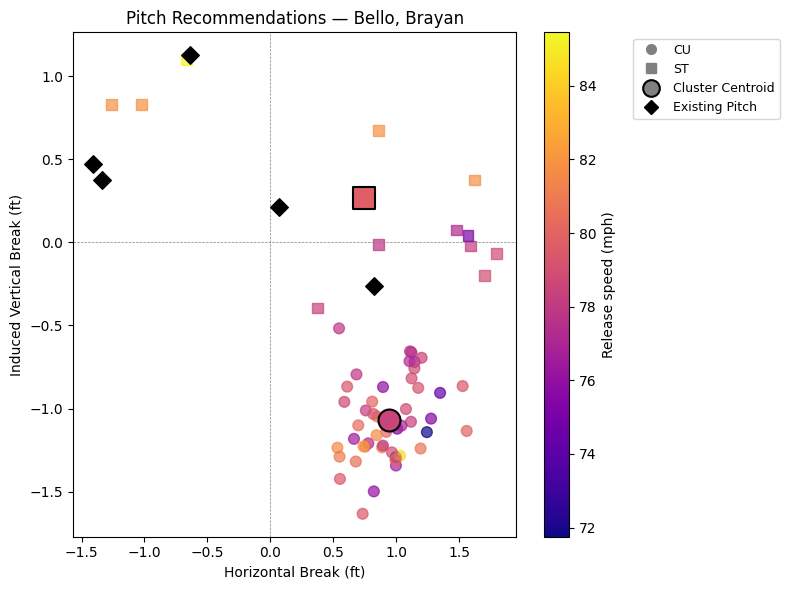

In [49]:
plot_pitch_clusters(b_bello)

## Bulk runs

In [64]:
l_bulk = run_suggest_pitches_bulk(pitcher_summ_l, pitch_type_summ, 
                                  min_pitches=50,
                                  biomech_distance_threshold=1.5,  
                                  novelty_distance_threshold=1.5,  
                                  min_comp_usage_pct=0.01)

In [65]:
l_bulk[0]

,target_pitcher,cluster_label,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,pitch_types_in_cluster,comp_pitchers
0,"Hill, Rich",SL,15,79.8,-0.81,-0.22,1.67,79.7,-0.83,-0.22,"CU, KC, SL, ST, SV","Alexander, Scott, Alexander, Tyler, Bleier, Ri..."
1,"Wilson, Justin",CU,56,78.7,-0.80,-0.73,2.31,78.4,-0.79,-0.76,"CU, KC, SL, ST, SV","Abbott, Andrew, Allard, Kolby, Allen, Logan, B..."
2,"Wilson, Justin",SI,10,93.0,1.34,0.86,1.59,92.4,1.33,0.89,"CH, SI","Banuelos, Manny, Borucki, Ryan, Jay, Tyler, Ma..."
3,"Kershaw, Clayton",ST,6,79.0,-1.09,-0.06,1.86,78.9,-1.09,-0.06,"SL, ST, SV","Allen, Logan, Davidson, Tucker, Guenther, Sean..."
4,"Kershaw, Clayton",CU,3,80.9,-0.16,-0.58,1.62,80.9,-0.15,-0.57,CU,"Cameron, Noah, Montgomery, Jordan, Zimmermann,..."
...,...,...,...,...,...,...,...,...,...,...,...,...
278,"Messick, Parker",CU,11,79.1,-0.22,-0.84,1.67,79.2,-0.21,-0.79,"CU, KC","Cameron, Noah, Freeland, Kyle, Gonzales, Marco..."
279,"Messick, Parker",CH,1,80.9,0.97,1.38,1.72,80.9,0.97,1.38,CH,"Means, John"
280,"Early, Connelly",CH,5,83.9,1.15,0.86,1.60,84.0,1.15,0.86,CH,"Corbin, Patrick, García, Jarlín, Hall, DL, Lyn..."
281,"Farris, Mitch",CU,29,76.3,-0.84,-0.86,1.93,75.8,-0.84,-0.90,"CU, KC, SL, ST","Benjamin, Wes, Bubic, Kris, Buchter, Ryan, Dav..."


In [66]:
l_bulk[1]

,target_pitcher,status,n_comps,n_suggestions
0,"Hill, Rich",ok,33,1
1,"Wilson, Justin",ok,115,2
2,"Kershaw, Clayton",ok,28,2
3,"Miley, Wade",ok,142,2
4,"Quintana, Jose",ok,102,2
...,...,...,...,...
193,"Sommers, Drew",no_comps,0,0
194,"Gibson, Cade",no_novel_pitches,113,0
195,"Early, Connelly",ok,62,1
196,"Farris, Mitch",ok,81,2


In [67]:
l_bulk[1][l_bulk[1]['status'] == 'no_comps']

,target_pitcher,status,n_comps,n_suggestions
49,"Perdomo, Angel",no_comps,0,0
52,"Krook, Matt",no_comps,0,0
87,"Morán, Jovani",no_comps,0,0
110,"Zimmermann, Bruce",no_comps,0,0
139,"Cosgrove, Tom",no_comps,0,0
142,"Walker, Josh",no_comps,0,0
145,"Cruz, Omar",no_comps,0,0
153,"Nikhazy, Doug",no_comps,0,0
155,"Little, Luke",no_comps,0,0
168,"La Sorsa, Joe",no_comps,0,0


In [60]:
d_sommers = suggest_pitches(
    target_pitcher='Sommers, Drew',
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.5,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

In [62]:
d_sommers['target_info']

pitcher                        805427
p_throws                            L
player_name             Sommers, Drew
game_year                        2025
release_pos_x                2.972308
release_pos_z                    4.76
release_extension            7.239744
arm_angle                   13.728205
n                                  78
max_velo                        93.45
max_spin                  2208.454545
pri_fb                             SI
fb_pfx_x                     1.341471
fb_n                             34.0
pri_fb_cd                           0
active_spin_fastball              NaN
FB_type                           NaN
Name: 4262, dtype: object